**Importing the dataset**



In [2]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("rafsanmahmud333333/cifar-10-attacked-dataset")



100%|██████████| 82.0M/82.0M [00:00<00:00, 178MB/s]

Extracting files...


**Data Preprocessing**

In [3]:
import os
import cv2
import pandas as pd
import numpy as np

# Set up paths to the dataset directory splits
base_path = os.path.join(path, "cifar10")
test_dir = os.path.join(base_path, "test")
clean_dir = os.path.join(test_dir, "clean")
fgsm_dir = os.path.join(test_dir, "fgsm")

# Load the test metadata to get the matching filenames and true labels
metadata_path = os.path.join(test_dir, "metadata_test(fgsm, bim, cANDw).csv")

if not os.path.exists(metadata_path):
    print(f"Error: Missing metadata file at {metadata_path}")
else:
    df_meta = pd.read_csv(metadata_path)

    # Filter metadata rows to select only the FGSM adversarial attack samples
    df_fgsm_meta = df_meta[df_meta['attack_type'] == 'fgsm']

    # Arrays to store the processed image matrices, noise residuals, and target labels
    clean_images = []
    fgsm_images = []
    noise_residuals = []
    labels = []

    print(f"Running data loading and image preprocessing for {len(df_fgsm_meta)} samples...")

    for index, row in df_fgsm_meta.iterrows():
        # Extract the raw filename string from the metadata path column
        full_path_str = row['image_path']
        filename = os.path.basename(full_path_str)
        true_label = row['original_label']

        clean_img_path = os.path.join(clean_dir, filename)
        fgsm_img_path = os.path.join(fgsm_dir, filename)

        if os.path.exists(clean_img_path) and os.path.exists(fgsm_img_path):
            # Load images as 2D coordinate matrices (uint8 arrays in BGR format)
            bgr_clean = cv2.imread(clean_img_path)
            bgr_fgsm = cv2.imread(fgsm_img_path)

            # Enforce identical M x N spatial dimensions (32x32)
            if bgr_clean.shape[:2] != (32, 32):
                bgr_clean = cv2.resize(bgr_clean, (32, 32), interpolation=cv2.INTER_AREA)
            if bgr_fgsm.shape[:2] != (32, 32):
                bgr_fgsm = cv2.resize(bgr_fgsm, (32, 32), interpolation=cv2.INTER_AREA)

            # Convert color space from BGR channel layout to standard RGB
            rgb_clean = cv2.cvtColor(bgr_clean, cv2.COLOR_BGR2RGB)
            rgb_fgsm = cv2.cvtColor(bgr_fgsm, cv2.COLOR_BGR2RGB)

            # Normalize pixel intensity values from [0, 255] to [0.0, 1.0] float space
            norm_clean = rgb_clean.astype(np.float32) / 255.0
            norm_fgsm = rgb_fgsm.astype(np.float32) / 255.0

            # Perform element-wise subtraction to isolate the adversarial noise matrix η(x,y)
            noise_matrix = norm_fgsm - norm_clean

            # Append matrices and labels to their respective lists
            clean_images.append(norm_clean)
            fgsm_images.append(norm_fgsm)
            noise_residuals.append(noise_matrix)
            labels.append(true_label)

    # Convert the collected image structures into final NumPy tensors
    X_clean = np.array(clean_images)
    X_fgsm = np.array(fgsm_images)
    X_noise = np.array(noise_residuals)
    y_test = np.array(labels)

    # Verification summary to check dataset tensor shapes
    print("\n--- Preprocessing Pipeline Verification ---")
    print(f"X_clean Matrix Shape : {X_clean.shape}")
    print(f"X_fgsm Matrix Shape  : {X_fgsm.shape}")
    print(f"X_noise Matrix Shape : {X_noise.shape}")
    print(f"y_test Target Shape  : {y_test.shape}")

Running data loading and image preprocessing for 500 samples...

--- Preprocessing Pipeline Verification ---
X_clean Matrix Shape : (500, 32, 32, 3)
X_fgsm Matrix Shape  : (500, 32, 32, 3)
X_noise Matrix Shape : (500, 32, 32, 3)
y_test Target Shape  : (500,)


**Evaluation and Analysis**

--- Matrix Information ---
Original Image Matrix Shape: (32, 32, 3)
Resized Image Matrix Shape: (256, 256, 3)

--- Evaluation Metrics ---
Gaussian Filter: MSE = 0.000023, MAE = 0.003169, PSNR = 46.45 dB <-- BEST
Median Filter: MSE = 0.000038, MAE = 0.003856, PSNR = 44.24 dB
Bilateral Filter: MSE = 0.000138, MAE = 0.008393, PSNR = 38.59 dB
Laplacian Enhancement: MSE = 0.000039, MAE = 0.004611, PSNR = 44.10 dB
Sharpening Filter: MSE = 0.247349, MAE = 0.481416, PSNR = 6.07 dB
Red Segmentation: MSE = 0.258231, MAE = 0.471936, PSNR = 5.88 dB


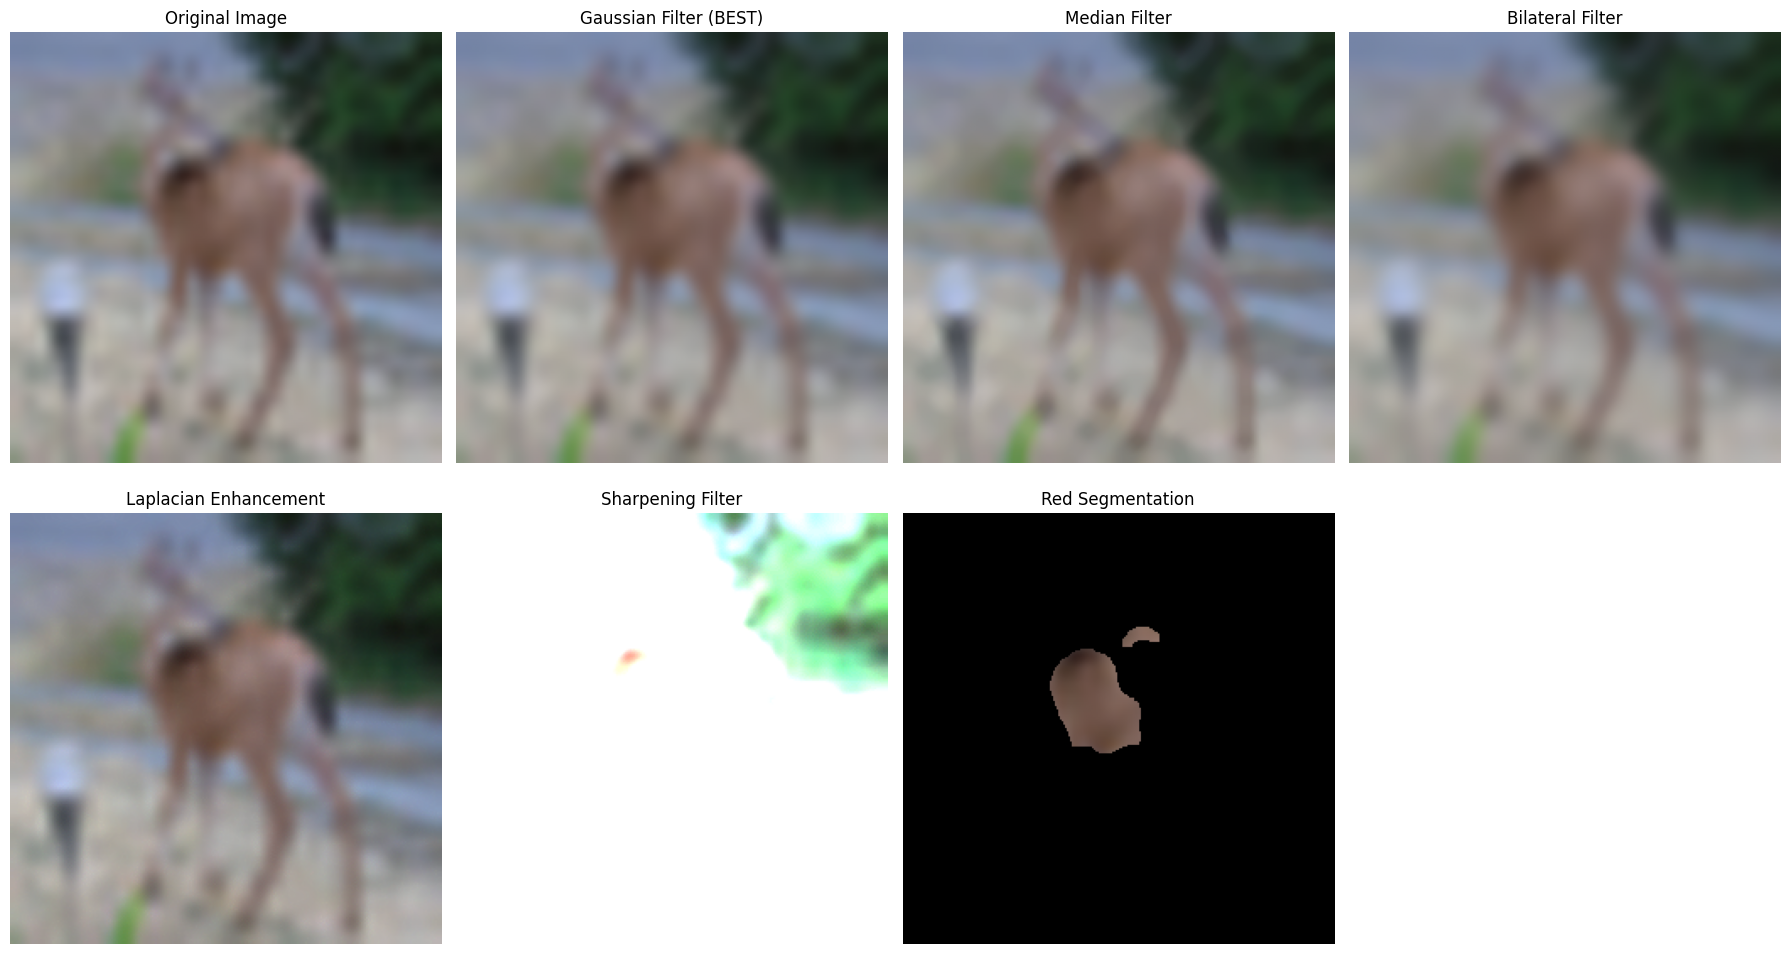


--- Analysis ---
Several image enhancement techniques were applied to the original CIFAR-10 image.
Gaussian and Median filters smooth the image and reduce pixelation.
Bilateral filtering smooths the image while preserving edges.
Laplacian enhancement increases edge visibility and highlights details.
Sharpening filtering improves edge contrast and image clarity.
Red color segmentation isolates the fire truck from the background using HSV color masking.
The best enhancement method based on the highest PSNR value is: Gaussian Filter.
Since CIFAR-10 images are originally low-resolution 32x32 images, enhancement improves visualization quality but cannot fully restore lost details.


In [6]:
# VI. Evaluation and Analysis: Image Enhancement Comparison

# Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Choose image index
sample_index = 100

# Select original clean image
original_img = X_clean[sample_index]

# Convert image from float [0,1] to uint8 [0,255]
original_uint8 = (original_img * 255).astype(np.uint8)

# Resize image for better visualization
resized_original = cv2.resize(
    original_uint8,
    (256, 256),
    interpolation=cv2.INTER_CUBIC
)

# Convert resized image to float
original_float = resized_original / 255.0

# ---------------------------------------------------
# Apply different image enhancement filters
# ---------------------------------------------------

# 1. Strong Gaussian Blur
gaussian_img = cv2.GaussianBlur(resized_original, (11, 11), 0)

# 2. Strong Median Filter
median_img = cv2.medianBlur(resized_original, 9)

# 3. Strong Bilateral Filter
bilateral_img = cv2.bilateralFilter(
    resized_original,
    15,
    150,
    150
)

# 4. Laplacian Enhancement
laplacian = cv2.Laplacian(resized_original, cv2.CV_64F)
laplacian = cv2.convertScaleAbs(laplacian)

laplacian_img = cv2.addWeighted(
    resized_original,
    1.0,
    laplacian,
    1.2,
    0
)

# 5. Strong Sharpening Filter
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 9, -1],
    [0, -1, 0]
])

sharpen_img = cv2.filter2D(
    resized_original,
    -1,
    sharpen_kernel
)

# 6. Red Color Segmentation
# Convert RGB image to HSV color space
hsv_img = cv2.cvtColor(resized_original, cv2.COLOR_RGB2HSV)

# Define lower and upper red color ranges
lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([180, 255, 255])

# Create red masks
mask1 = cv2.inRange(hsv_img, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_img, lower_red2, upper_red2)

# Combine masks
red_mask = mask1 + mask2

# Improve mask quality using morphology
kernel = np.ones((5, 5), np.uint8)

red_mask = cv2.morphologyEx(
    red_mask,
    cv2.MORPH_CLOSE,
    kernel
)

red_mask = cv2.morphologyEx(
    red_mask,
    cv2.MORPH_OPEN,
    kernel
)

# Apply segmentation mask
segmented_img = cv2.bitwise_and(
    resized_original,
    resized_original,
    mask=red_mask
)

# ---------------------------------------------------
# Store methods
# ---------------------------------------------------

methods = {
    "Gaussian Filter": gaussian_img,
    "Median Filter": median_img,
    "Bilateral Filter": bilateral_img,
    "Laplacian Enhancement": laplacian_img,
    "Sharpening Filter": sharpen_img,
    "Red Segmentation": segmented_img
}

# ---------------------------------------------------
# Calculate evaluation metrics
# ---------------------------------------------------

results = []

for method_name, enhanced_uint8 in methods.items():

    # Convert enhanced image to float
    enhanced_float = enhanced_uint8 / 255.0

    # Calculate MSE
    mse = mean_squared_error(
        original_float.flatten(),
        enhanced_float.flatten()
    )

    # Calculate MAE
    mae = mean_absolute_error(
        original_float.flatten(),
        enhanced_float.flatten()
    )

    # Calculate PSNR
    psnr = (
        20 * np.log10(1.0 / np.sqrt(mse))
        if mse != 0
        else float("inf")
    )

    # Save results
    results.append({
        "Method": method_name,
        "MSE": mse,
        "MAE": mae,
        "PSNR": psnr,
        "Image": enhanced_float
    })

# ---------------------------------------------------
# Select best enhancement method
# ---------------------------------------------------

best_result = max(results, key=lambda x: x["PSNR"])
best_method = best_result["Method"]

# ---------------------------------------------------
# Print matrix information
# ---------------------------------------------------

print("--- Matrix Information ---")
print("Original Image Matrix Shape:", original_img.shape)
print("Resized Image Matrix Shape:", original_float.shape)

# ---------------------------------------------------
# Print evaluation metrics
# ---------------------------------------------------

print("\n--- Evaluation Metrics ---")

for result in results:

    label = " <-- BEST" if result["Method"] == best_method else ""

    print(
        f"{result['Method']}: "
        f"MSE = {result['MSE']:.6f}, "
        f"MAE = {result['MAE']:.6f}, "
        f"PSNR = {result['PSNR']:.2f} dB"
        f"{label}"
    )

# ---------------------------------------------------
# Display images
# ---------------------------------------------------

plt.figure(figsize=(18, 10))

# Display original image
plt.subplot(2, 4, 1)
plt.imshow(original_float)
plt.title("Original Image")
plt.axis("off")

# Display filtered images
for i, result in enumerate(results, start=2):

    title = result["Method"]

    if result["Method"] == best_method:
        title += " (BEST)"

    plt.subplot(2, 4, i)
    plt.imshow(result["Image"])
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------
# Print analysis
# ---------------------------------------------------

print("\n--- Analysis ---")

print("Several image enhancement techniques were applied to the original CIFAR-10 image.")

print("Gaussian and Median filters smooth the image and reduce pixelation.")

print("Bilateral filtering smooths the image while preserving edges.")

print("Laplacian enhancement increases edge visibility and highlights details.")

print("Sharpening filtering improves edge contrast and image clarity.")

print("Red color segmentation isolates the fire truck from the background using HSV color masking.")

print(f"The best enhancement method based on the highest PSNR value is: {best_method}.")

print("Since CIFAR-10 images are originally low-resolution 32x32 images, enhancement improves visualization quality but cannot fully restore lost details.")